In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [2]:
df = pd.read_csv('../data/clean_audio_data.csv')
df.drop(columns=['participant_id'], inplace=True)

## 1. Select Features

In [3]:
# Reduce feature set based on RF importance
selected_features = [
    'hnr_dev', 
    'hnr', 
    'pause_count_dev', 
    'pause_count', 
    'energy_range_dev', 
    'duration', 
    'energy_range', 
    'duration_dev', 
    'pause_max', 
    'speech_rate', 
    'speech_rate_dev', 
    'verbal_hesitation_count', 
    'energy_std_dev', 
    'mfcc_2_mean', 
    'mfcc_2_mean_dev', 
]

In [4]:
# Drop non-feature columns
X = df[selected_features]
y = df['difficulty_level']

In [5]:
# handle missing values
X = X.astype(float)
X = X.fillna(X.mean())

In [6]:
# train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # important for class balance
)

## 2. Train Logistic Regression & Extract Weights

In [7]:
# train
clf = LogisticRegression(
    solver='lbfgs',
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)
clf.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [8]:
print(clf.coef_.shape)  # (n_classes, n_features)
print(clf.intercept_.shape)  # (n_classes,)

(3, 15)
(3,)


In [9]:
# inspect coefficients
coefficients = clf.coef_     
intercept = clf.intercept_    

coef_df = pd.DataFrame({
    "feature": selected_features,
    "coefficient": coefficients[0]
}).sort_values(by="coefficient", ascending=False)

print(coef_df)

                    feature  coefficient
3               pause_count     0.478250
8                 pause_max     0.229682
5                  duration     0.132183
6              energy_range     0.127553
14          mfcc_2_mean_dev     0.014385
7              duration_dev     0.012535
12           energy_std_dev    -0.003682
2           pause_count_dev    -0.004824
4          energy_range_dev    -0.046972
0                   hnr_dev    -0.219559
10          speech_rate_dev    -0.267120
1                       hnr    -0.352957
13              mfcc_2_mean    -0.403657
11  verbal_hesitation_count    -0.424326
9               speech_rate    -0.424361


## 3. Predict Class Labels Manually & Evaluate

Predicted class labels (manual): ['low' 'high' 'high' 'medium' 'low' 'low' 'medium' 'high' 'high' 'medium'
 'low' 'high' 'high' 'high' 'high']

Classification Report:

              precision    recall  f1-score   support

        high       0.50      1.00      0.67         4
         low       0.75      0.38      0.50         8
      medium       0.33      0.33      0.33         3

    accuracy                           0.53        15
   macro avg       0.53      0.57      0.50        15
weighted avg       0.60      0.53      0.51        15



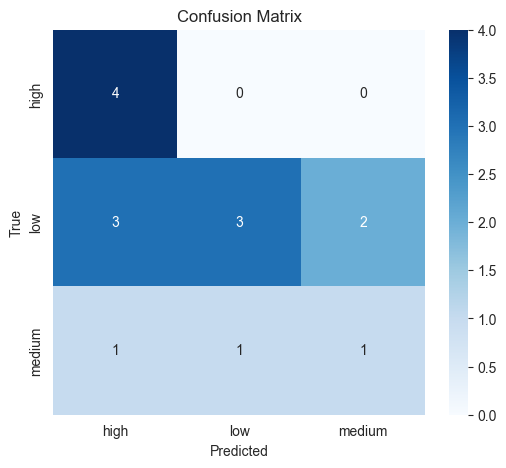

In [10]:
# --- 1. Extract model parameters ---
coef = clf.coef_          # (n_classes, n_features)
intercept = clf.intercept_  # (n_classes,)
feature_names = X_test.columns

# --- 2. Compute raw scores ---
X_array = X_test.values
z = np.dot(X_array, coef.T) + intercept  # shape: (n_samples, n_classes)

# --- 3. Softmax to get probabilities ---
def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))  # numerical stability
    return exp_z / exp_z.sum(axis=1, keepdims=True)

y_probs_manual = softmax(z)

# --- 4. Predict numeric class indices ---
y_pred_indices = np.argmax(y_probs_manual, axis=1)

# --- 5. Map numeric indices back to string labels ---
y_pred_manual = clf.classes_[y_pred_indices]  # e.g., ['low', 'high', 'medium', ...]

print("Predicted class labels (manual):", y_pred_manual)

# --- 6. Classification report ---
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_manual))

# --- 7. Confusion matrix ---
cm = confusion_matrix(y_test, y_pred_manual, labels=clf.classes_)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=clf.classes_, yticklabels=clf.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

## Evaluate entire dataset

Predicted class labels (manual) for full dataset:
 ['low' 'high' 'low' 'high' 'medium' 'low' 'low' 'low' 'low' 'high' 'high'
 'high' 'high' 'high' 'medium' 'medium' 'high' 'low' 'low' 'low' 'low'
 'high' 'high' 'low' 'medium' 'high' 'low' 'low' 'medium' 'low' 'high'
 'high' 'low' 'high' 'low' 'low' 'medium' 'high' 'low' 'low' 'low' 'high'
 'medium' 'medium' 'low' 'high' 'high' 'high' 'low' 'low' 'medium'
 'medium' 'low' 'low' 'low' 'high' 'medium' 'low' 'medium' 'low' 'medium'
 'high' 'low' 'high' 'low' 'medium' 'high' 'low' 'medium' 'high' 'high']

Classification Report:

              precision    recall  f1-score   support

        high       0.60      0.83      0.70        18
         low       0.81      0.64      0.71        39
      medium       0.53      0.57      0.55        14

    accuracy                           0.68        71
   macro avg       0.65      0.68      0.65        71
weighted avg       0.70      0.68      0.68        71



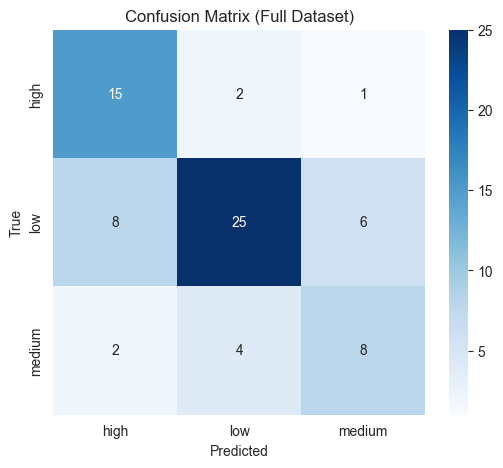

In [11]:
X_array = X.values  # full dataset features
y_true = y           # full dataset labels (strings or numeric)

z = np.dot(X_array, coef.T) + intercept  # shape: (n_samples, n_classes)

y_probs_manual = softmax(z)

y_pred_indices = np.argmax(y_probs_manual, axis=1)
y_pred_manual = clf.classes_[y_pred_indices]  # match label type of y_true

print("Predicted class labels (manual) for full dataset:\n", y_pred_manual)

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred_manual))

cm = confusion_matrix(y_true, y_pred_manual, labels=clf.classes_)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=clf.classes_, yticklabels=clf.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Full Dataset)")
plt.show()

The model achieves an overall accuracy of 68% on the dataset. It predicts the “high” class with strong recall (0.83) but moderate precision (0.60), indicating most high instances are correctly identified, though some predictions are incorrect. The “low” class has high precision (0.81) but lower recall (0.64), meaning predictions labeled low are usually correct, but some actual low instances are missed. The “medium” class is the weakest, with both precision (0.53) and recall (0.57), showing the model struggles to distinguish it from the other classes. Overall, performance is moderate, with certain classes predicted more reliably than others.